In [ ]:

import math
# user input & given parameters
M=3.3e13 # kg (33,000 million tons)
P_hr=16.16 # hours
omega=2*math.pi/(P_hr*3600) # rad/8

print(f"Omega:{omega:.7f}rad/s")

# Let's assume a radius r based on a diameter of say 4 km-> R=2000 m
R=2000
ac=(omega**2)*R #centrifugal accel
G=6.6743e-11
g=G*M/(R**2) # surface gravitiy
print(f"Centrifugal accel:{ac:.7f}m/s^2")
print(f"Surface gravity: {g:.7f}m/s^2")


Omega:0.0001080rad/s
Centrifugal accel:0.0000233m/s^2
Surface gravity: 0.0005506m/s^2


In [ ]:
import numpy as np

# 1. Parámetros del Cometa (Datos del Usuario + consenso
Masa = 3.3e13    # Masa rela corregida en kg (33,000 millones de toneladas)
Densidad = 500   # Tu valor ajustado a la mita del agua (500 kg/m^3)
Periodo_horas = 16.16       # Tu periodo de rotación

# 2. Geometría e Hidrodinámica del Gas
Desviacion_grados = 8.0 # Ängulo de inclinación del chorro
V_gas = 500.0           # Velocidad del plasma/gas en m/s
G = 6.6743e-11          # Constante de gravitación universal

# 3. Cálculos Dinámicos Derivados
# Radio equivalente esférico basado en tu densidad y masa
Radio = (3* Masa/ (4* np.pi)/Densidad)**(1/3)

# Velocidad angular (rad/s) y gravedad superficial
Omega = (2* np.pi) / (Periodo_horas * 3600)
Gravedad_superficial = G * Masa / (Radio**2)

# Fuerza centrífuga en el ecuador
A_centrifuga = Omega**2 * Radio

print(f"---PARÁMETROS CALCULADOS PARA TU MODELO---")
print(f"Radio efectivo del núcleo: {Radio:.7f} metros")
print(f"Gravedad en superficie: {Gravedad_superficial:.7f} m/s^2")
print(f"Alivio centrífugo en el ecuador: {(A_centrifuga / Gravedad_superficial)*100:.2f}% de la gravedad")

---PARÁMETROS CALCULADOS PARA TU MODELO---
Radio efectivo del núcleo: 2506.9852306 metros
Gravedad en superficie: 0.0003504 m/s^2
Alivio centrífugo en el ecuador: 8.34% de la gravedad


In [ ]:
import numpy as np

# Constantes para la ecuación de Clasusius-Claperyon (Ejemplo  para CO2)
# P = P0 * exp (-l / (R * T))
P0 = 1.0e12              # Factor de escala de presión (Pa)
L = 25000                # Calor Latente de sublimación estimado (J/mol)
R = 8.314                # Constante universal de los gases (J/mol)

def calcular_presion_y_estres(T_kelvin, r_poro=0.1, espesor_capa=1.0):
  """
Calcula la presión interna del gas y el estrés estructural en la corteza.

T_kelvin: Temperatura en Kelvin. Puede ser un escalar o un array de numpy.
r_poro: Radio del poro o cavidad interna en metros.
espesor_capa: Espesor de la corteza de hielo sobre el poro en metros.
              Puede ser un escalar o un array de numpy.
  """
  # 1. Presión de vapor interna mediante Clausius-Clapeyron
  # np.exp funciona tanto para escalares como para arrays
  P_interna = P0 * np.exp(-L / (R * T_kelvin))

  # 2. Estrés de tracción en la corteza (Fórmula de recipiente a presión esférico)
  # Las operaciones son element-wise si espesor_capa es un array. NumPy gestiona el broadcasting.
  Estres_mecanico = (P_interna * r_poro) / (2 * espesor_capa)

  # 3. Factor de asistencia rotacional en el ecuador (resta cohesión efectiva)
  Alivio_rotacional = 0.0034
  Estres_neto = Estres_mecanico * (1 + Alivio_rotacional)

  return P_interna, Estres_neto

# Ejemplo de prueba original (seguirá funcionando con escalares)
T_simulacion = 200
P, sigma = calcular_presion_y_estres(T_simulacion)

print(f"A una temperatura de {T_simulacion} K:")
print(f"Presión interna del poro: {P/1000:.2f} kPa")
print(f"-> Estrés neto en la corteza ecuatorial: {sigma/1000:.2f} kPa")

A una temperatura de 200 K:
Presión interna del poro: 295.42 kPa
-> Estrés neto en la corteza ecuatorial: 14.82 kPa


### Visualización del Estrés Neto con Múltiples Temperaturas y Espesores de Corteza

Podemos usar las capacidades vectorizadas de la función `calcular_presion_y_estres` para explorar el estrés neto en un rango de temperaturas y espesores de corteza. Un mapa de calor es una excelente manera de visualizar esta relación multidimensional.

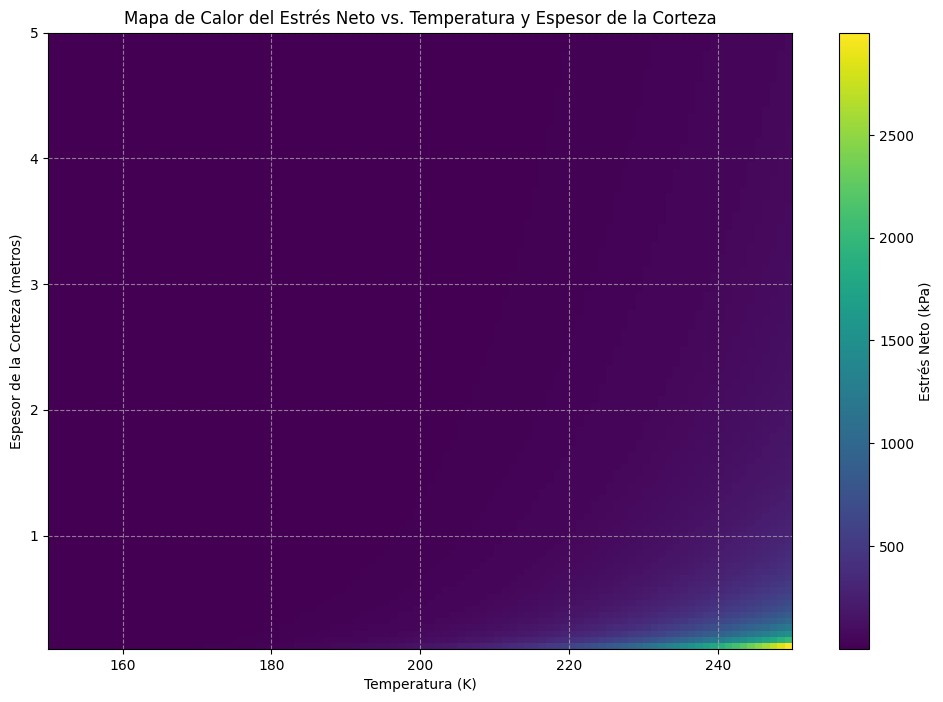

In [ ]:
import matplotlib.pyplot as plt

# Definir rangos para la temperatura y el espesor de la corteza
Temperaturas_rango = np.linspace(150, 250, 100) # De 150 K a 250 K
Espesores_rango = np.linspace(0.1, 5.0, 100) # De 0.1 metros a 5.0 metros

# Crear una malla de puntos para la evaluación simultánea
T_grid, Espesor_grid = np.meshgrid(Temperaturas_rango, Espesores_rango)

# Calcular el estrés neto para cada combinación de T y espesor
# La función ahora maneja arrays directamente
_, Estres_neto_grid = calcular_presion_y_estres(T_grid, espesor_capa=Espesor_grid)

# Convertir el estrés neto de Pa a kPa para una mejor legibilidad
Estres_neto_grid_kPa = Estres_neto_grid / 1000

# Crear el mapa de calor
plt.figure(figsize=(12, 8))
c = plt.imshow(
    Estres_neto_grid_kPa,
    origin='lower',
    extent=[Temperaturas_rango.min(), Temperaturas_rango.max(), Espesores_rango.min(), Espesores_rango.max()],
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(c, label='Estrés Neto (kPa)')
plt.title('Mapa de Calor del Estrés Neto vs. Temperatura y Espesor de la Corteza')
plt.xlabel('Temperatura (K)')
plt.ylabel('Espesor de la Corteza (metros)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Tabla Resumen: Temperaturas Críticas vs. Espesor de la Corteza

Para resumir cómo el espesor de la corteza afecta la estabilidad del cometa, calcularemos la temperatura crítica (donde el estrés neto excede los 100 kPa) para varios espesores de la corteza. Esto nos dará una tabla de umbrales de falla.

In [ ]:
import pandas as pd

# Resistencia del material en kPa (ya definida)
material_strength_kPa = 100

# Rangos de temperatura y espesor (ya definidos en el heatmap)
# Temperaturas_rango = np.linspace(150, 250, 100)
# Espesores_rango = np.linspace(0.1, 5.0, 100)

# Seleccionar algunos espesores de la corteza representativos para la tabla
espesores_para_tabla = np.array([0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0]) # en metros

critical_temperatures_by_thickness = []

for espesor in espesores_para_tabla:
    critical_temp = None
    for temp in Temperaturas_rango: # Iterar sobre el rango de temperaturas
        _, Estres_neto = calcular_presion_y_estres(temp, espesor_capa=espesor)
        if (Estres_neto / 1000) >= material_strength_kPa: # Convertir Pa a kPa para comparación
            critical_temp = temp
            break
    critical_temperatures_by_thickness.append({
        'Espesor de la Corteza (m)': espesor,
        'Temperatura Crítica (K)': critical_temp
    })

# Crear un DataFrame de pandas
df_resumen = pd.DataFrame(critical_temperatures_by_thickness)

# Mostrar la tabla
display(df_resumen)


,Espesor de la Corteza (m),Temperatura Crítica (K)
0,0.1,195.454545
1,0.5,217.676768
2,1.0,229.797980
3,2.0,241.919192
4,3.0,NaN
5,4.0,NaN
6,5.0,NaN


In [ ]:
# Exportar el DataFrame a un archivo CSV
df_resumen.to_csv('umbrales_falla_cometa.csv', index=False)
print('Tabla exportada a umbrales_falla_cometa.csv')

Tabla exportada a umbrales_falla_cometa.csv


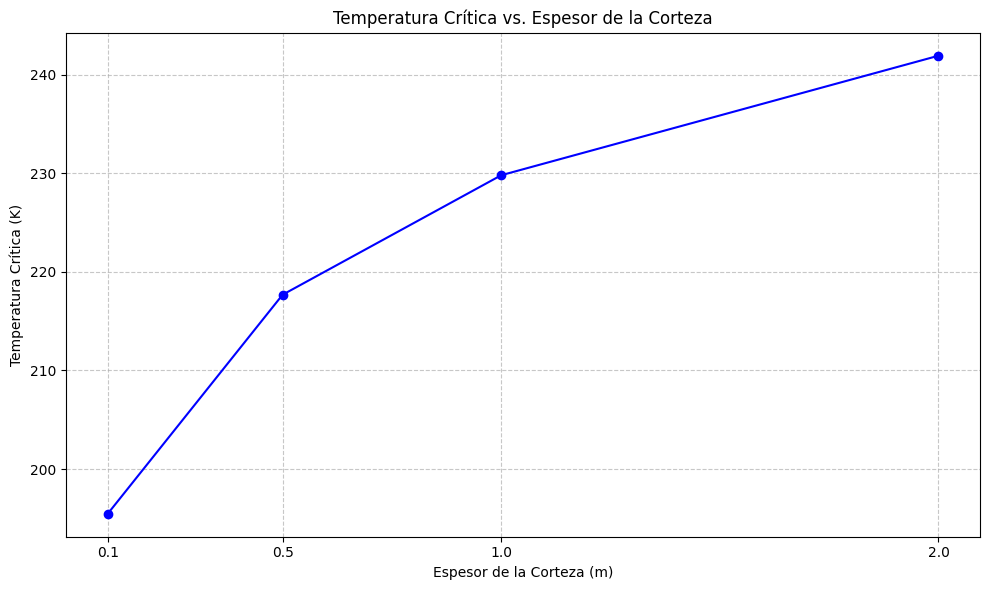

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegúrate de que df_resumen esté cargado, si no lo está, cárgalo del CSV
# Si ya está en memoria, esta línea no es estrictamente necesaria pero asegura que los datos estén disponibles
try:
    df_resumen = pd.read_csv('umbrales_falla_cometa.csv')
except FileNotFoundError:
    print('El archivo umbrales_falla_cometa.csv no se encontró. Asegúrate de haberlo exportado.')

# Filtrar filas con temperaturas críticas NaN para no plotearlas, o manejarlas como desees
df_plot = df_resumen.dropna(subset=['Temperatura Crítica (K)'])

plt.figure(figsize=(10, 6))
plt.plot(
    df_plot['Espesor de la Corteza (m)'],
    df_plot['Temperatura Crítica (K)'],
    marker='o', # Agrega marcadores para puntos individuales
    linestyle='-', # Conecta los puntos con una línea
    color='b'
)
plt.title('Temperatura Crítica vs. Espesor de la Corteza')
plt.xlabel('Espesor de la Corteza (m)')
plt.ylabel('Temperatura Crítica (K)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_plot['Espesor de la Corteza (m)']) # Muestra todos los valores de espesor en el eje X
plt.tight_layout()
plt.show()

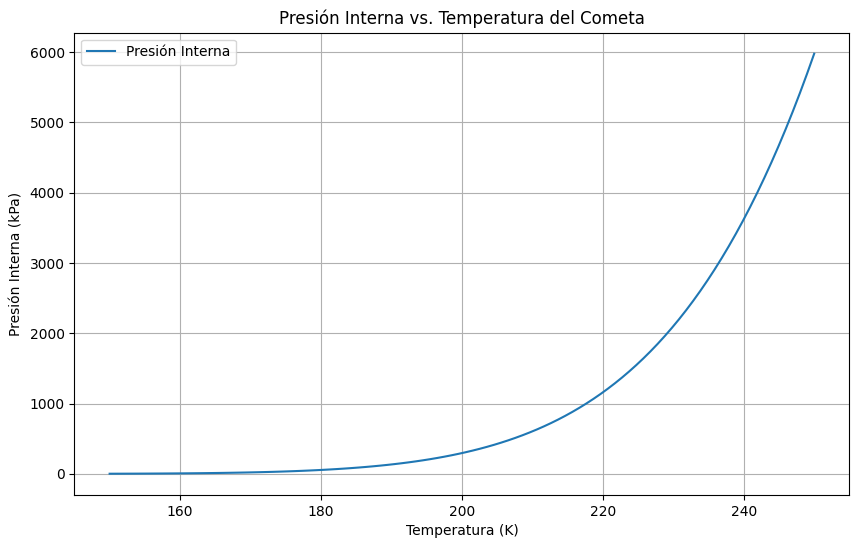

In [ ]:
import matplotlib.pyplot as plt

# Define a range of temperatures
temperatures = np.linspace(150, 250, 100) # From 150 K to 250 K with 100 points

# Calculate internal pressure for each temperature
internal_pressures = []
for temp in temperatures:
    P_interna, _ = calcular_presion_y_estres(temp)
    internal_pressures.append(P_interna / 1000) # Convert Pa to kPa

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(temperatures, internal_pressures, label='Presión Interna')
plt.title('Presión Interna vs. Temperatura del Cometa')
plt.xlabel('Temperatura (K)')
plt.ylabel('Presión Interna (kPa)')
plt.grid(True)
plt.legend()
plt.show()

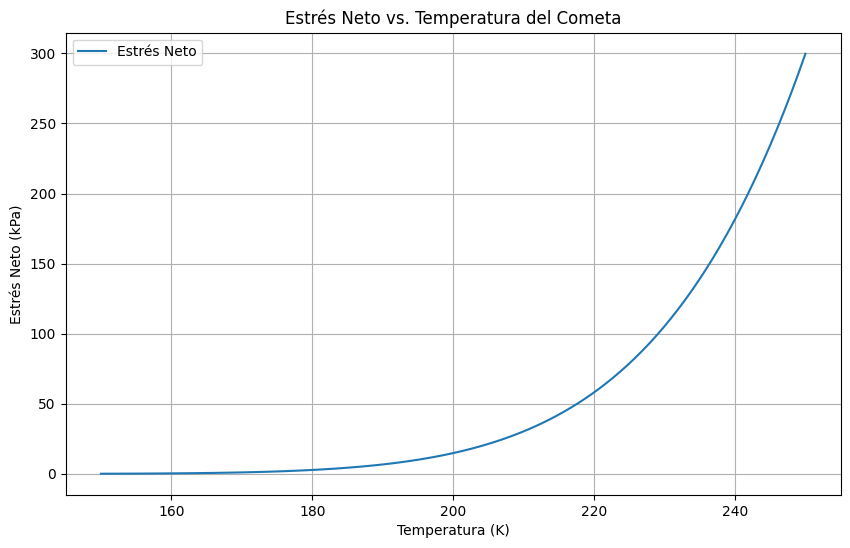

In [ ]:
import matplotlib.pyplot as plt

# Calculate net stress for each temperature
net_stresses = []
for temp in temperatures:
    _, Estres_neto = calcular_presion_y_estres(temp)
    net_stresses.append(Estres_neto / 1000) # Convert Pa to kPa

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(temperatures, net_stresses, label='Estrés Neto')
plt.title('Estrés Neto vs. Temperatura del Cometa')
plt.xlabel('Temperatura (K)')
plt.ylabel('Estrés Neto (kPa)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Define the material strength (e.g., tensile strength of ice)
material_strength_kPa = 100  # kPa (100 kPa = 0.1 MPa)

critical_temperature = None
for i, stress in enumerate(net_stresses):
    if stress >= material_strength_kPa:
        critical_temperature = temperatures[i]
        break

if critical_temperature:
    print(f"La temperatura crítica donde el estrés neto supera {material_strength_kPa} kPa es: {critical_temperature:.2f} K")
else:
    print(f"El estrés neto nunca supera {material_strength_kPa} kPa en el rango de temperatura simulado ({temperatures.min():.0f}K - {temperatures.max():.0f}K).")

La temperatura crítica donde el estrés neto supera 100 kPa es: 229.80 K


### Impacto del Espesor de la Corteza en el Estrés Neto

El estrés mecánico en la corteza es inversamente proporcional a su espesor. Una corteza más gruesa puede soportar mejor la presión interna, lo que resulta en un menor estrés neto. Por el contrario, una corteza más delgada experimentará un mayor estrés.

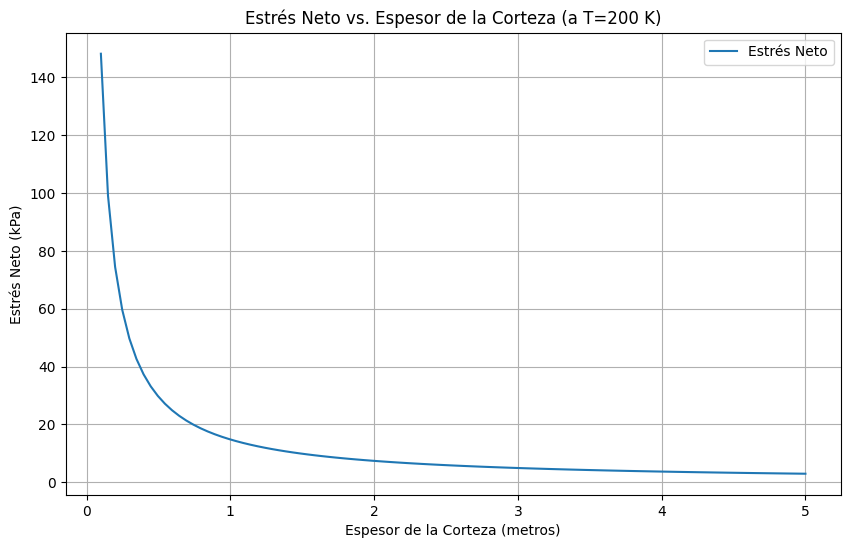

In [ ]:
import matplotlib.pyplot as plt

# Definimos un rango de espesores de la corteza para simular (en metros)
cortezas_espesores = np.linspace(0.1, 5.0, 100) # De 0.1 metros a 5.0 metros

# Usamos la temperatura de simulación anterior (e.g., 200 K)
T_simulacion_fija = 200 # K

# Calculamos el estrés neto para cada espesor de corteza
net_stresses_por_espesor = []
for espesor in cortezas_espesores:
    _, Estres_neto = calcular_presion_y_estres(T_simulacion_fija, espesor_capa=espesor)
    net_stresses_por_espesor.append(Estres_neto / 1000) # Convertir Pa a kPa

# Creamos la gráfica
plt.figure(figsize=(10, 6))
plt.plot(cortezas_espesores, net_stresses_por_espesor, label='Estrés Neto')
plt.title('Estrés Neto vs. Espesor de la Corteza (a T=200 K)')
plt.xlabel('Espesor de la Corteza (metros)')
plt.ylabel('Estrés Neto (kPa)')
plt.grid(True)
plt.legend()
plt.show()